### Task-1: Effect of Loss Functions on Convergence Speed

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [90]:
data = fetch_california_housing()

X = data.data     
y = data.target

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print(pd.DataFrame(X).head())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Feature shape: (20640, 8)
Target shape: (20640,)
        0     1         2         3       4         5      6       7
0  8.3252  41.0  6.984127  1.023810   322.0  2.555556  37.88 -122.23
1  8.3014  21.0  6.238137  0.971880  2401.0  2.109842  37.86 -122.22
2  7.2574  52.0  8.288136  1.073446   496.0  2.802260  37.85 -122.24
3  5.6431  52.0  5.817352  1.073059   558.0  2.547945  37.85 -122.25
4  3.8462  52.0  6.281853  1.081081   565.0  2.181467  37.85 -122.25


##### Loss Functions

In [91]:
def mse_loss(y, y_pred):
    return 0.5*np.mean((y - y_pred) ** 2)

def mse_grad(X, y, y_pred):
    error = y_pred - y                 
    dw = (1/len(y)) * (X.T @ error)   
    db = (1/len(y)) * np.sum(error)
    return dw, db

def mae_loss(y, y_pred):
    return np.mean(np.abs(y - y_pred))

def mae_grad(X, y, y_pred):
    error = y_pred - y             
    grad = np.sign(error)              
    dw = (1 / len(y)) * (X.T @ grad)    
    db = (1 / len(y)) * np.sum(grad)
    return dw, db

def huber_loss(y, y_pred, delta=1.0):
    error = y - y_pred
    mask = np.abs(error) <= delta
    squared = 0.5 * error**2
    linear = delta * (np.abs(error) - 0.5 * delta)
    return np.mean(np.where(mask, squared, linear))

def huber_grad(X, y, y_pred, delta=1.0):
    error = y_pred - y
    grad = np.where(
        np.abs(error) <= delta,
        error,
        delta * np.sign(error)
    )
    dw = (1 / len(y)) * (X.T @ grad)    
    db = (1 / len(y)) * np.sum(grad)
    return dw, db

In [92]:
def predict(X, w, b):
    return X @ w + b  

def train(loss_fn, grad_fn, X, y, lr=0.01, epochs=10000, grad_tol=1e-3):
    w = np.zeros(X.shape[1])  
    b = 0.0
    losses = []

    for epoch in range(epochs):
        y_pred = predict(X, w, b)
        loss = loss_fn(y, y_pred)
        losses.append(loss)

        dw, db = grad_fn(X, y, y_pred)
        grad_norm = np.sqrt(np.sum(dw**2) + db**2)
        if grad_norm < grad_tol:
            break
            
        w -= lr * dw
        b -= lr * db

    return w, b, losses, epoch + 1

Epochs to convergence:
MSE   : 3381
MAE   : 8335
Huber : 3550


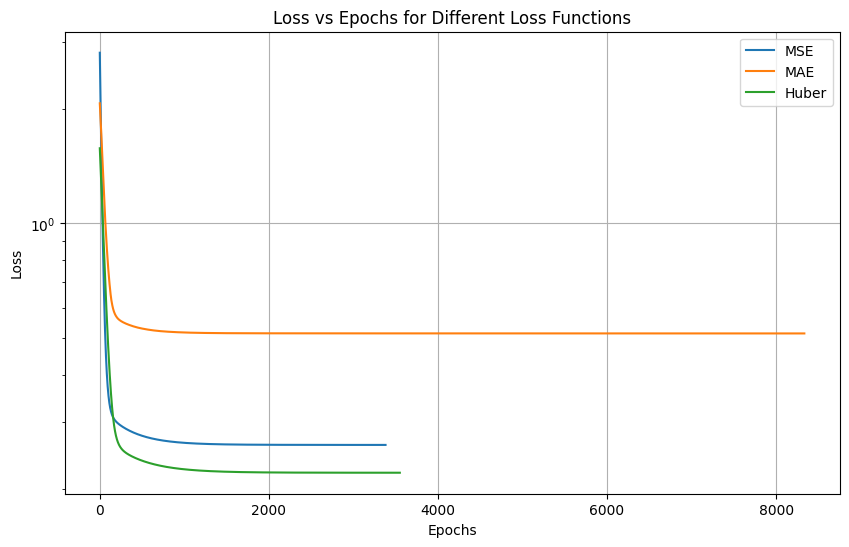

In [93]:
w_mse,b_mse,mse_losses,mse_epochs=train(mse_loss, mse_grad, X_train_scaled, y_train, lr=0.02)
w_mae,b_mae,mae_losses,mae_epochs=train(mae_loss, mae_grad, X_train_scaled, y_train, lr=0.02)
w_huber,b_huber,huber_losses,huber_epochs=train(huber_loss, huber_grad, X_train_scaled, y_train, lr=0.02)


print("Epochs to convergence:")
print("MSE   :", mse_epochs)
print("MAE   :", mae_epochs)
print("Huber :", huber_epochs)

plt.figure(figsize=(10, 6))
plt.plot(mse_losses, label="MSE")
plt.plot(mae_losses, label="MAE")
plt.plot(huber_losses, label="Huber")
plt.yscale("log")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs for Different Loss Functions")
plt.legend()
plt.grid(True)
plt.show()

### Task 2: Robustness to Outliers

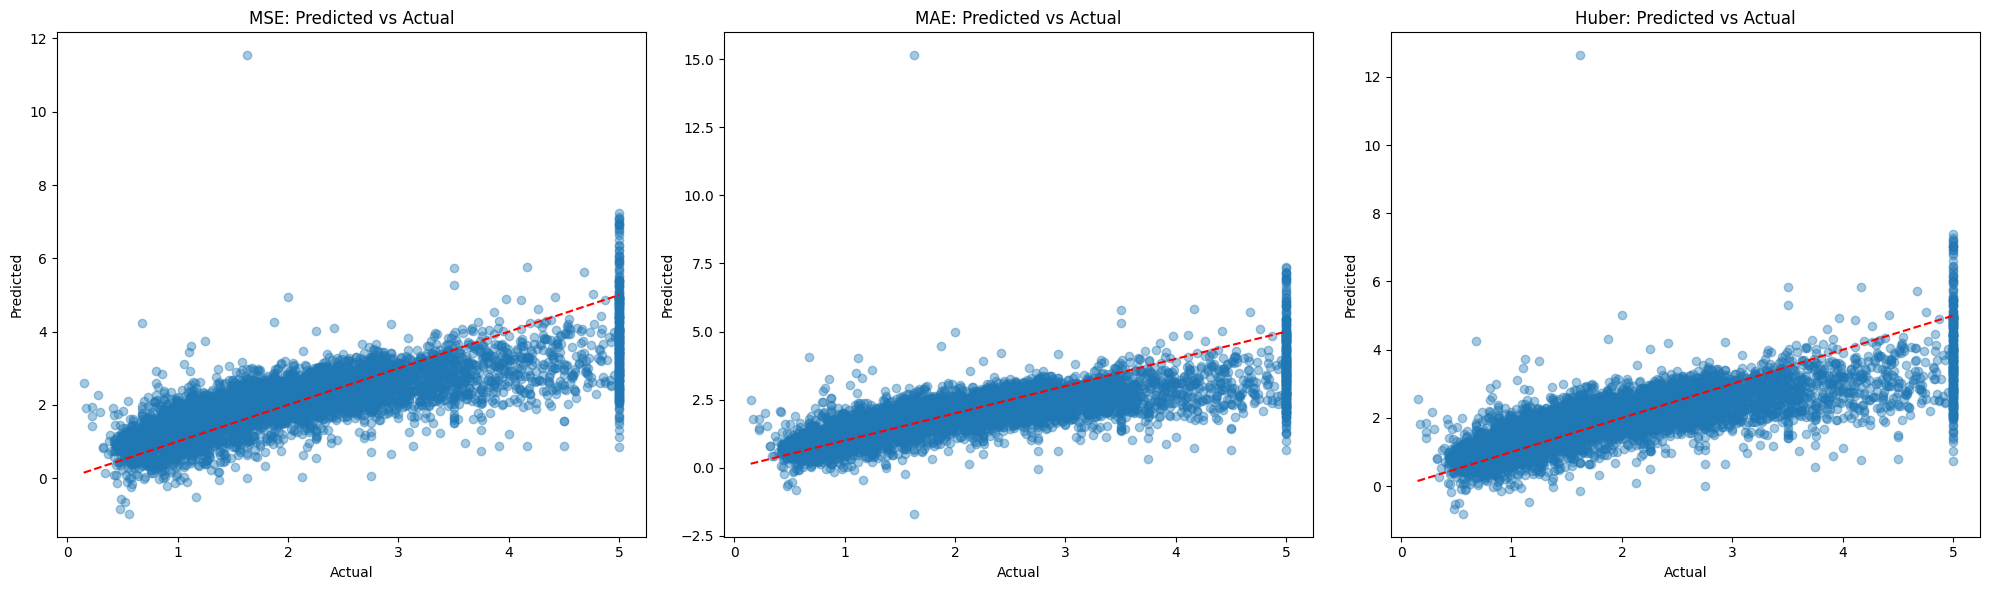

In [94]:
y_pred_mse = predict(X_test_scaled, w_mse, b_mse)
y_pred_mae = predict(X_test_scaled, w_mae, b_mae)
y_pred_huber = predict(X_test_scaled, w_huber, b_huber)

plt.figure(figsize=(20, 6))
plt.subplot(1, 3, 1)
plt.scatter(y_test, y_pred_mse, alpha=0.4)
plt.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()], 'r--')
plt.title("MSE: Predicted vs Actual")
plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.subplot(1, 3, 2)
plt.scatter(y_test, y_pred_mae, alpha=0.4)
plt.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()], 'r--')
plt.title("MAE: Predicted vs Actual")
plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.subplot(1, 3, 3)
plt.scatter(y_test, y_pred_huber, alpha=0.4)
plt.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()], 'r--')
plt.title("Huber: Predicted vs Actual")
plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.tight_layout()
plt.show()
